In [ ]:
#question1
import tensorflow as tf
tf.random.set_seed(42)

t1 = tf.constant([1,2,3,4,5])
t2 = tf.random.normal(shape=(3,3))
v1 = tf.Variable(tf.zeros((2,4)))
for name, t in [('Tensor 1', t1), ('Tensor 2', t2), ('Variable', v1)]:
 print(f'{name}  shape:{t.shape}  dtype:{t.dtype.name}  rank:{tf.rank(t).numpy()}')

Tensor 1  shape:(5,)  dtype:int32  rank:1
Tensor 2  shape:(3, 3)  dtype:float32  rank:2
Variable  shape:(2, 4)  dtype:float32  rank:2


In [ ]:
#question 2
import tensorflow as tf
tf.random.set_seed(42)
A = tf.random.normal(shape=(2,3))
B = tf.random.normal(shape=(2,3))
print('A shape :', A)
print('B shape :', B)
print('A + B shape :', tf.add(A,B).shape)
print('A * B shape :', (A*B).shape)
print('A @ B.T     :', tf.matmul(A, tf.transpose(B)).shape)
print('Mean of A   :', tf.reduce_mean(A).numpy())

A shape : tf.Tensor(
[[ 0.3274685 -0.8426258  0.3194337]
 [-1.4075519 -2.3880599 -1.0392479]], shape=(2, 3), dtype=float32)
B shape : tf.Tensor(
[[ 0.08422458 -0.86090374  0.37812304]
 [-0.00519627 -0.49453196  0.6178192 ]], shape=(2, 3), dtype=float32)
A + B shape : (2, 3)
A * B shape : (2, 3)
A @ B.T     : (2, 2)
Mean of A   : -0.8384306


In [ ]:
# question 3
import tensorflow as tf
from tensorflow import keras
model = keras.Sequential([
keras.layers.Dense(128, activation='relu', input_shape=(784,)),
keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#question 4
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(784,)),
    keras.layers.Dense(10, activation='softmax')
])


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('Optimizer:', model.optimizer.get_config()['name'])
print('Loss     :', model.loss)
print('Metrics  :', [m.name for m in model.metrics])

Optimizer: adam
Loss     : sparse_categorical_crossentropy
Metrics  : ['loss', 'compile_metrics']


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#question 5
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(42)
(X_tr, y_tr), (X_te, y_te) = keras.datasets.mnist.load_data()
X_tr = X_tr.reshape(-1, 784) / 255.0
X_te = X_te.reshape(-1, 784) / 255.0
# YOUR CODE HERE — build, compile, fit, evaluate
model = keras.Sequential([    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')])
model.compile(optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
history = model.fit(X_tr, y_tr, epochs=5, batch_size=128, validation_split=0.1,
verbose=1)
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Test accuracy: {acc:.4f}')

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9013 - loss: 0.3530 - val_accuracy: 0.9597 - val_loss: 0.1414
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9563 - loss: 0.1467 - val_accuracy: 0.9675 - val_loss: 0.1056
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9695 - loss: 0.1025 - val_accuracy: 0.9722 - val_loss: 0.0936
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9779 - loss: 0.0767 - val_accuracy: 0.9748 - val_loss: 0.0835
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9827 - loss: 0.0599 - val_accuracy: 0.9758 - val_loss: 0.0804
Test accuracy: 0.9730


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8954 - loss: 0.3712 - val_accuracy: 0.9588 - val_loss: 0.1421
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9562 - loss: 0.1475 - val_accuracy: 0.9677 - val_loss: 0.1064
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9692 - loss: 0.1031 - val_accuracy: 0.9732 - val_loss: 0.0925
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9778 - loss: 0.0768 - val_accuracy: 0.9748 - val_loss: 0.0887
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9827 - loss: 0.0589 - val_accuracy: 0.9742 - val_loss: 0.0893
Test accuracy: 0.9716


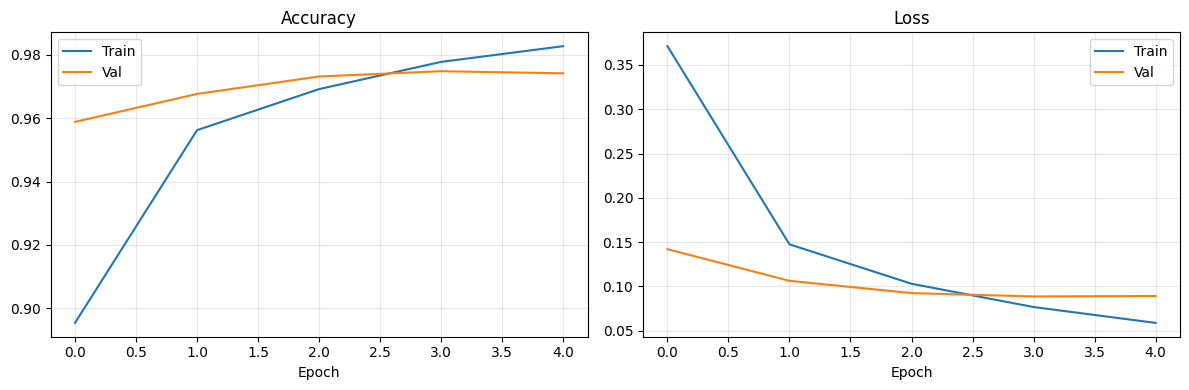

In [ ]:
#question 6
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

tf.random.set_seed(42)

(X_tr, y_tr), (X_te, y_te) = keras.datasets.mnist.load_data()
X_tr = X_tr.reshape(-1, 784) / 255.0
X_te = X_te.reshape(-1, 784) / 255.0


model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64,  activation='relu'),
    keras.layers.Dense(10,  activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_tr, y_tr,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Test accuracy: {acc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('tf_history.png', dpi=100)
plt.show()

In [ ]:
#question 7
from tensorflow import keras
import tensorflow as tf
tf.random.set_seed(42)

(X_tr, y_tr), (X_te, y_te) = keras.datasets.mnist.load_data()
X_tr = X_tr.reshape(-1,784)/255.0
X_te = X_te.reshape(-1,784)/255.0

model_drop = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax')
])
model_drop.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
hist = model_drop.fit(X_tr, y_tr, epochs=5, batch_size=128,
validation_split=0.1, verbose=0)
print('Final val_accuracy with Dropout:', round(hist.history['val_accuracy'][
1], 4))

model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64,  activation='relu'),
    keras.layers.Dense(10,  activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    X_tr, y_tr,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)
print('Final val_accuracy without Dropout:', round(history2.history['val_accuracy'][
1], 4))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final val_accuracy with Dropout: 0.9672
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9002 - loss: 0.3606 - val_accuracy: 0.9608 - val_loss: 0.1428
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9549 - loss: 0.1526 - val_accuracy: 0.9692 - val_loss: 0.1060
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9686 - loss: 0.1063 - val_accuracy: 0.9728 - val_loss: 0.0890
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9764 - loss: 0.0796 - val_accuracy: 0.9755 - val_loss: 0.0844
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9825 - loss: 0.0610 - val_accuracy: 0.9760 - val_loss: 0.0826
Final val_accuracy without Dropout: 0.9692


In [ ]:
#quesstion 8
from tensorflow import keras
import tensorflow as tf
tf.random.set_seed(42)

(X_tr, y_tr), (X_te, y_te) = keras.datasets.mnist.load_data()
X_tr = X_tr.reshape(-1,784)/255.0
X_te = X_te.reshape(-1,784)/255.0

model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
model.fit(X_tr, y_tr, epochs=3, batch_size=128, verbose=0)


model.save('dpp.keras')
loaded = keras.models.load_model('dpp.keras')
_,orig_acc  = model.evaluate(X_te, y_te, verbose=0)
_,load_acc  = loaded.evaluate(X_te, y_te, verbose=0)
print(f'Original  accuracy: {orig_acc:.4f}')
print(f'Loaded    accuracy: {load_acc:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Original  accuracy: 0.9712
Loaded    accuracy: 0.9712


In [ ]:
#question 9
from tensorflow import keras
import tensorflow as tf
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
tf.random.set_seed(42)

X, y = load_breast_cancer(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)


model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(X_tr.shape[1],)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_tr, y_tr, epochs=20, batch_size=32, validation_split=0.15, verbose=0)
_, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Test Accuracy: {acc:.4f}')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 0.9912


In [ ]:
#question 10
from tensorflow import keras
import tensorflow as tf, numpy as np
tf.random.set_seed(42)

class_names = ['T-shirt','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

(X_tr, y_tr), (X_te, y_te) = keras.datasets.fashion_mnist.load_data()
X_tr = X_tr.reshape(-1,784)/255.0
X_te = X_te.reshape(-1,784)/255.0
y_tr_oh = keras.utils.to_categorical(y_tr, 10)
y_te_oh = keras.utils.to_categorical(y_te, 10)

model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(X_tr.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy',
metrics=['accuracy'])
model.fit(X_tr, y_tr_oh, epochs=10, batch_size=128, validation_split=0.1, verbose=0)
_, acc = model.evaluate(X_te, y_te_oh, verbose=0)
print(f'Test accuracy: {acc:.4f}')
pred = np.argmax(model.predict(X_te[:1], verbose=0))
print('Predicted class:', class_names[pred])

Test accuracy: 0.8842
Predicted class: Ankle boot


In [ ]:
#question 11

from tensorflow import keras
import tensorflow as tf
tf.random.set_seed(42)

(X_tr, y_tr), (X_te, y_te) = keras.datasets.mnist.load_data()
X_tr = X_tr.reshape(-1,28,28,1) / 255.0
X_te = X_te.reshape(-1,28,28,1) / 255.0

cnn = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
cnn.fit(X_tr, y_tr, epochs=5, batch_size=64, validation_split=0.1, verbose=1)
_, acc = cnn.evaluate(X_te, y_te, verbose=0)
print(f'CNN Test Accuracy: {acc:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 49ms/step - accuracy: 0.9430 - loss: 0.1870 - val_accuracy: 0.9820 - val_loss: 0.0661
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9832 - loss: 0.0546 - val_accuracy: 0.9837 - val_loss: 0.0515
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.9884 - loss: 0.0374 - val_accuracy: 0.9850 - val_loss: 0.0508
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - accuracy: 0.9916 - loss: 0.0266 - val_accuracy: 0.9855 - val_loss: 0.0520
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.9943 - loss: 0.0194 - val_accuracy: 0.9880 - val_loss: 0.0488
CNN Test Accuracy: 0.9872


In [ ]:
#question 12
from tensorflow import keras
import tensorflow as tf
tf.random.set_seed(42)

(X_tr, y_tr), (X_te, y_te) = keras.datasets.mnist.load_data()
X_tr = X_tr.reshape(-1, 784) / 255.0
X_te = X_te.reshape(-1, 784) / 255.0

model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    keras.layers.Dense(64,  activation='relu'),
    keras.layers.Dense(10,  activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

es = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)
mc = keras.callbacks.ModelCheckpoint(
    'best_mnist.keras',
    save_best_only=True
)

history = model.fit(
    X_tr, y_tr,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    callbacks=[es, mc],
    verbose=0
)

print(f'Training stopped at epoch: {len(history.history["loss"])}')

loaded = keras.models.load_model('best_mnist.keras')
_, loaded_acc = loaded.evaluate(X_te, y_te, verbose=0)
print(f'Loaded checkpoint accuracy: {loaded_acc:.4f}')

_, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Test accuracy: {acc:.4f}')

Training stopped at epoch: 10
Loaded checkpoint accuracy: 0.9749
Test accuracy: 0.9749


In [ ]:
#question 13
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

tf.random.set_seed(42)

X, y = load_iris(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_tr = sc.fit_transform(X_tr).astype('float32')
X_te = sc.transform(X_te).astype('float32')

model = keras.Sequential([
    keras.layers.Dense(32, activation='relu', input_shape=(4,)),
    keras.layers.Dense(3,  activation='softmax')
])

loss_fn   = keras.losses.SparseCategoricalCrossentropy()
optimizer = keras.optimizers.Adam(learning_rate=0.01)

for epoch in range(1, 101):
    with tf.GradientTape() as tape:
        logits = model(X_tr, training=True)
        loss   = loss_fn(y_tr, logits)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    if epoch % 20 == 0:
        preds = tf.argmax(model(X_tr), axis=1).numpy()
        acc   = (preds == y_tr).mean()
        print(f'Epoch {epoch:3d} -- loss: {loss:.4f} -- accuracy: {acc:.3f}')

test_preds = tf.argmax(model(X_te), axis=1).numpy()
test_acc   = (test_preds == y_te).mean()
print(f'\nTest accuracy: {test_acc:.3f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch  20 -- loss: 0.3341 -- accuracy: 0.875
Epoch  40 -- loss: 0.1751 -- accuracy: 0.958
Epoch  60 -- loss: 0.0953 -- accuracy: 0.967
Epoch  80 -- loss: 0.0683 -- accuracy: 0.967
Epoch 100 -- loss: 0.0585 -- accuracy: 0.983

Test accuracy: 1.000


In [ ]:
#question 14
from tensorflow import keras
import tensorflow as tf
tf.random.set_seed(42)

(X_tr, y_tr), (X_te, y_te) = keras.datasets.fashion_mnist.load_data()
X_tr = X_tr.reshape(-1,784)/255.0
X_te = X_te.reshape(-1,784)/255.0


plain = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(784,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10,  activation='softmax')
])

reg = keras.regularizers.l2(0.001)
bn_model = keras.Sequential([
    keras.layers.Dense(256, activation='relu', kernel_regularizer=reg,
input_shape=(784,)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu', kernel_regularizer=reg),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(10, activation='softmax')
])

for name, m in [('Plain', plain), ('BN+L2', bn_model)]:
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
metrics=['accuracy'])
    h = m.fit(X_tr, y_tr, epochs=10, batch_size=128, validation_split=0.1,
verbose=0)
    print(f'{name} val_accuracy: {h.history["val_accuracy"][-1]:.4f}  params: {m.count_params()}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Plain val_accuracy: 0.8848  params: 235146
BN+L2 val_accuracy: 0.8413  params: 236682


In [ ]:
#question 15
from tensorflow import keras
import tensorflow as tf
import numpy as np

tf.random.set_seed(42)

base = keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)
base.trainable = False

model = keras.Sequential([
    base,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

X_dummy = np.random.rand(200, 96, 96, 3).astype('float32')
y_dummy = np.random.randint(0, 10, 200)

model.fit(X_dummy, y_dummy, epochs=3, batch_size=16, verbose=1)

trainable     = sum(tf.size(w).numpy() for w in model.trainable_weights)
non_trainable = sum(tf.size(w).numpy() for w in model.non_trainable_weights)

print(f'Trainable params     : {trainable:,}')
print(f'Non-trainable params : {non_trainable:,}')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.1150 - loss: 2.6060
Epoch 2/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.1150 - loss: 2.3373
Epoch 3/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - accuracy: 0.1650 - loss: 2.2917
Trainable params     : 82,634
Non-trainable params : 2,257,984
